## Treasury zero rate estimation using t-bond data


### t-bond data

In [5]:
from x01_data import parse_macroevent, bond_pricing

country = "KR"
df = parse_macroevent(f"x01_gvt_{country}.csv")

In [6]:
## Bond Pricing. It uses B-bond auction price as market price of bond.

from dateutil import relativedelta
import pandas as pd 

df["Bond principal"] = 100
df["Maturity Date"] = [pd.to_datetime(x) for x in ["2027-09","2028-12","2030-09","2035-12","2045-09","2055-09","2074-09",]]
df["Issue Date"] = [(y - pd.offsets.DateOffset(years=x)) for x,y in df["Maturity Date"].items()]
df["Annual coupon"] = [x*2 for x in [2.250,2.750,2.500,3.250,2.750,2.625,2.750]]
df["TTM"] = df.apply(lambda x: relativedelta.relativedelta(x["Maturity Date"], x["Settle Date"]), axis=1).map(lambda x: x.years + x.months/12 + x.days / 360)
# Let's not forget to multiply 0.01
df["Bond price (Inferred)"] = df.apply(lambda x: bond_pricing(100, 2, 0.01 * x["Annual coupon"], 0.01 * x["Bond Yield"], x["Issue Date"], x["Maturity Date"], x["Settle Date"])[1], axis=1)

df

,Settle Date,Bond Yield,Bond principal,Maturity Date,Issue Date,Annual coupon,TTM,Bond price (Inferred)
Maturity,,,,,,,,
2,2025-12-01,2.876,100,2027-09-01,2025-09-01,4.50,1.750000,103.874850
3,2025-12-08,2.970,100,2028-12-01,2025-12-01,5.50,2.980556,107.270996
5,2025-12-22,3.245,100,2030-09-01,2025-09-01,5.00,4.694444,109.118230
10,2025-12-15,3.410,100,2035-12-01,2025-12-01,6.50,9.961111,126.159855
20,2025-12-23,3.365,100,2045-09-01,2025-09-01,5.50,19.691667,132.262560
30,2025-12-02,3.225,100,2055-09-01,2025-09-01,5.25,29.750000,139.871567
50,2025-12-12,3.140,100,2074-09-01,2024-09-01,5.50,48.722222,NaN


In [7]:
# Similar with Hull Table 4.3
df1 = df[["Bond principal", "TTM", "Annual coupon", "Bond price (Inferred)", "Bond Yield"]]
df1

,Bond principal,TTM,Annual coupon,Bond price (Inferred),Bond Yield
Maturity,,,,,
2,100,1.750000,4.50,103.874850,2.876
3,100,2.980556,5.50,107.270996,2.970
5,100,4.694444,5.00,109.118230,3.245
10,100,9.961111,6.50,126.159855,3.410
20,100,19.691667,5.50,132.262560,3.365
30,100,29.750000,5.25,139.871567,3.225
50,100,48.722222,5.50,NaN,3.140


### Bootstrap method 

In this example, some data is interpolated. 

The result can be improved by using more data, or better model 

In [8]:
import numpy as np 
import pandas as pd
import sympy as sp 

# Starting date we set for the zero rate.
d0 = pd.to_datetime("2025-12-01") 

# Utility functions
def impl_intoFloat_for_dt(d0, d):
    total_seconds =  (d - d0).total_seconds()
    return total_seconds

def impl_fromFloat_for_dt(d0, x):
    return d0 + pd.Timedelta(seconds=x)

def dates_into_year(d1, d2):
    assert(d1 < d2)
    x = relativedelta.relativedelta(d2, d1)
    return x.years + x.months/12 + x.days / 360

def year_into_date(d1, x):
    return d1 + pd.offsets.DateOffset(years=x)

def get_coupon_dates(issue_date, maturity_date, freq):
    months = {1:12, 2:6, 4:3, 12:1}[freq]
    return pd.date_range(issue_date, maturity_date, freq=pd.DateOffset(months=months))[1:]


In [9]:

# Let's use linear interopolation model to infer the zero rate curve from the data points.
# from scipy.interpolate import interp1d
import numpy as np 
class Interp1d:
    def __init__(self, d0=None):
        self.xys:List[Tuple[float, float]] = []
        self.d0 = d0
    @property
    def xy(self):
        x,y = zip(*self.xys)
        return x, y
    def interpolate(self, x):
        if len(self.xys) == 0 : return np.nan
        else : return self._interpolate(x)
    # def _interpolate(self, x:float) -> float:
    #     return np.interp(x, self.xs, self.ys, None, np.nan)
    def _interpolate(self, x:pd.Timestamp) -> float:
        xs, ys = self.xy
        return np.interp(impl_intoFloat_for_dt(self.d0, x), xs, ys, None, np.nan) # bfill only, no-ffill
    def add_data(self, x, y):
        self._add_data(x,y)
        self.xys.sort(key=lambda z : z[0], reverse=False)
    # def _add_data(self, x:float, y:float):
    #     self.xs += [x]
    #     self.ys += [y]
    def _add_data(self, x:pd.Timestamp, y:float):
        self.xys += [(impl_intoFloat_for_dt(self.d0, x), y)]
    @property
    def empty(self):
        return False if self.xys else True


In [10]:
zero_rate_model = Interp1d(d0=d0)

for i,x in df.dropna().iterrows(): # Bootstrap - like
    principal_amt = 100
    freq = 2 

    coupon_dates = get_coupon_dates(x["Issue Date"], x["Maturity Date"], freq=freq)
    coupon_dates_yr = [dates_into_year(x["Settle Date"], t) for t in coupon_dates]
    coupon_amt = principal_amt * x["Annual coupon"] * 0.01 / freq 
    
    # x["Bond Yield"] is not continuous compounding (it is calculated based on the equation in the acution notice document)
    # x["Bond Price"] is inferred value, but it is not ambiguous.
    pv = x["Bond price (Inferred)"] # LHS
    pv_explained = 0 # RHS-to-be
    unprocessed_cashflows = [] # List(date, td_yr, amount)

    for date, td_yr in zip(coupon_dates, coupon_dates_yr):
        zero_rate = zero_rate_model.interpolate(date)
        if np.isfinite(zero_rate):
            pv_explained += np.exp( - zero_rate / freq * td_yr )
        else:
            unprocessed_cashflows += [(date, td_yr, coupon_amt)]
    unprocessed_cashflows += [(coupon_dates[-1], coupon_dates_yr[-1], principal_amt)]
    
    # Let's use sympy for easier debugging
    # x["Bond Price"] = coupon_amt * np.sum(np.exp ( continuous_bond_yield -  * x["coupon_dates_in_years"] )) + principal_amt * np.exp ( continuous_bond_yield * x["coupon_dates_in_years"].iloc[-1] )
    r_unknown = sp.symbols('r', real=True)
    pv_unexplained = pv - pv_explained

    # Warning : It is is not financially correct to assume constant zero rate curve 
    pv_unprocessed_cashflows = sum([cashflow * sp.exp(-yr * r_unknown / freq) for _, yr, cashflow in unprocessed_cashflows])
    equation = sp.Eq(pv_explained + pv_unexplained, pv_explained + pv_unprocessed_cashflows)
    display(equation)
    initial_soln = 0 if zero_rate_model.empty else zero_rate_model.xy[1][-1]
    estim_r = float(sp.nsolve(equation, r_unknown, initial_soln))

    for date in set([date for date, _, _ in unprocessed_cashflows]):
        # print(date, estim_r)
        zero_rate_model.add_data(date, estim_r)
    

Eq(103.874850352058, 102.25*exp(-0.875*r) + 2.25*exp(-0.625*r) + 2.25*exp(-0.375*r) + 2.25*exp(-0.125*r))

Eq(107.270996412918, 2.91723285179501 + 102.75*exp(-1.49027777777778*r) + 2.75*exp(-1.24166666666667*r) + 2.75*exp(-0.990277777777778*r))

Eq(109.118230476509, 5.83464654629714 + 102.5*exp(-2.34722222222222*r) + 2.5*exp(-2.09305555555556*r) + 2.5*exp(-1.84722222222222*r) + 2.5*exp(-1.59305555555556*r))

Eq(126.159855036156, 8.67066715165942 + 103.25*exp(-4.98055555555556*r) + 3.25*exp(-4.73194444444444*r) + 3.25*exp(-4.48055555555556*r) + 3.25*exp(-4.23194444444444*r) + 3.25*exp(-3.98055555555556*r) + 3.25*exp(-3.73194444444444*r) + 3.25*exp(-3.48055555555556*r) + 3.25*exp(-3.23194444444444*r) + 3.25*exp(-2.98055555555556*r) + 3.25*exp(-2.73194444444444*r) + 3.25*exp(-2.48055555555556*r))

Eq(132.262560277376, 18.5360298018257 + 102.75*exp(-9.84583333333333*r) + 2.75*exp(-9.59166666666667*r) + 2.75*exp(-9.34583333333333*r) + 2.75*exp(-9.09305555555556*r) + 2.75*exp(-8.84583333333333*r) + 2.75*exp(-8.59166666666667*r) + 2.75*exp(-8.34583333333333*r) + 2.75*exp(-8.09166666666667*r) + 2.75*exp(-7.84583333333333*r) + 2.75*exp(-7.59166666666667*r) + 2.75*exp(-7.34583333333333*r) + 2.75*exp(-7.09305555555556*r) + 2.75*exp(-6.84583333333333*r) + 2.75*exp(-6.59166666666667*r) + 2.75*exp(-6.34583333333333*r) + 2.75*exp(-6.09166666666667*r) + 2.75*exp(-5.84583333333333*r) + 2.75*exp(-5.59166666666667*r) + 2.75*exp(-5.34583333333333*r) + 2.75*exp(-5.09305555555556*r))

Eq(139.871567207046, 33.9738387623726 + 102.625*exp(-14.875*r) + 2.625*exp(-14.6208333333333*r) + 2.625*exp(-14.375*r) + 2.625*exp(-14.1208333333333*r) + 2.625*exp(-13.875*r) + 2.625*exp(-13.6208333333333*r) + 2.625*exp(-13.375*r) + 2.625*exp(-13.1222222222222*r) + 2.625*exp(-12.875*r) + 2.625*exp(-12.6208333333333*r) + 2.625*exp(-12.375*r) + 2.625*exp(-12.1208333333333*r) + 2.625*exp(-11.875*r) + 2.625*exp(-11.6208333333333*r) + 2.625*exp(-11.375*r) + 2.625*exp(-11.1222222222222*r) + 2.625*exp(-10.875*r) + 2.625*exp(-10.6208333333333*r) + 2.625*exp(-10.375*r) + 2.625*exp(-10.1208333333333*r))

## Result comparison 

Naive estimation of treasury zero rate is especially inaccurate for short-term zero rate.

This mismatch is mainly caused by the wrong assumption : constant short-term zero rate (flat curve around zero).

<Axes: title={'center': 'Zero-Coupon Bond Yield, as of 2025-12-01 00:00:00'}, xlabel='year'>

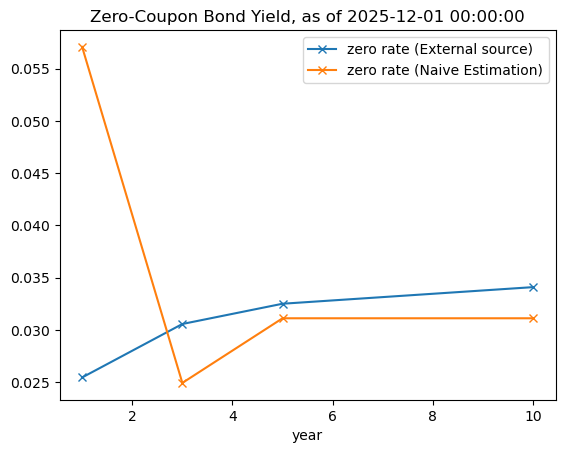

In [ ]:
# df_zero = pd.DataFrame({
#     "time": [impl_fromFloat_for_dt(d0, x) for x in zero_rate_model.xy[0]], 
#     "zero rate": [y for y in zero_rate_model.xy[1]]
# }).sort_values("time")
# df_zero["year"] = df_zero["time"].map(lambda x : dates_into_year(d0, x))
# df_zero.plot.scatter(x="year", y="zero rate", title=f"Naive estimation of zero rate, as of {d0}")

df_zero_external_source = pd.DataFrame({
    "year": [1, 3, 5, 10],
    "zero rate (External source)": [x*0.01 for x in [2.544, 3.056, 3.250, 3.409]], # South Korea Zero-Coupon Bond Yield as of 2025-12-01
    "zero rate (Naive Estimation)": [zero_rate_model.interpolate(year_into_date(d0, t)) for t in [1, 3, 5, 10]],
}).set_index("year")

df_zero_external_source.plot(title=f"Zero-Coupon Bond Yield, as of {d0}", marker="x")